`Imports`

In [1]:
import re
import json
import random
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

WIKI_URL = "https://en.wikipedia.org/wiki/Gundam"
RANDOM_SEED = 42

print("Libraries imported successfully!")

Libraries imported successfully!


`NLTK Setup`

In [2]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

ensure_nltk()
print("NLTK ready.")

NLTK ready.


`Fetch Wikipedia Article`

In [3]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {"User-Agent": "Mozilla/5.0 (compatible; SGNS-Gundam-Training/1.0)"}
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = [p.get_text(" ", strip=True) for p in paragraphs if p.get_text(" ", strip=True)]
    text = "\n".join(text_blocks)
    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Downloading Wikipedia article...")
raw_text = fetch_wikipedia_article(WIKI_URL)
print(f"Article fetched. Total characters: {len(raw_text)}")
print("\nPreview (first 500 chars):")
print(raw_text[:500])

Article fetched. Total characters: 34841

Preview (first 500 chars):
Hajime Yatate Yoshiyuki Tomino Gundam ( Japanese : ガンダムシリーズ , Hepburn : Gandamu Shirīzu ; lit. Gundam Series ) is a Japanese military science fiction media franchise . Created by Yoshiyuki Tomino for Sunrise (now a division of Bandai Namco Filmworks ), the franchise features giant robots, or mecha , known as "Mobile Suits", typically including a prominent one carrying the name "Gundam". [ 1 ] [ better source needed ] The franchise began with the premiere of the anime series Mobile Suit Gundam on


`Preprocess Text`

In [4]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)
    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue
        tokens = word_tokenize(sent)
        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok or tok.isdigit() or len(tok) < 2:
                continue
            cleaned.append(tok)
        if len(cleaned) >= 3:
            processed.append(cleaned)
    return processed

def corpus_stats(sentences):
    flat = [w for s in sentences for w in s]
    return {
        "num_sentences": len(sentences),
        "num_tokens":    len(flat),
        "vocab_size":    len(set(flat))
    }

print("Preprocessing text...")
sentences = preprocess_text(raw_text)
stats = corpus_stats(sentences)

print("\n=== Corpus Stats ===")
for k, v in stats.items():
    print(f"  {k}: {v}")

Preprocessing text...

=== Corpus Stats ===
  num_sentences: 260
  num_tokens: 3952
  vocab_size: 1481


`Helper Functions`

In [5]:
def has_word(model, word):
    return word in model.wv.key_to_index

def cosine(model, w1, w2):
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

def evaluate_relatedness(model, test_pairs):
    gold, pred, covered = [], [], []
    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))
    return {"covered_items": covered, "coverage": len(covered), "total": len(test_pairs)}

def evaluate_analogies(model, analogies):
    covered = correct = 0
    details = []
    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy":        f"{a}:{b}::{c}:?",
                    "expected":       d,
                    "predictions":    predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass
    return {
        "coverage":       covered,
        "total":          len(analogies),
        "accuracy_top5":  correct / covered if covered else float("nan"),
        "details":        details
    }

def print_top_neighbors(model, words, topn=8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

print("Helper functions defined.")

Helper functions defined.


`Train Both Models`

In [6]:
def train_sgns(sentences: List[List[str]], window: int = 5) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=window,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Training Model A — window=5 (original)...")
model_w5 = train_sgns(sentences, window=5)
print("  Done.")

print("Training Model B — window=10 (updated)...")
model_w10 = train_sgns(sentences, window=10)
print("  Done.")

print(f"\nVocab size (window=5)  : {len(model_w5.wv)}")
print(f"Vocab size (window=10) : {len(model_w10.wv)}")

Training Model A — window=5 (original)...
  Done.
Training Model B — window=10 (updated)...
  Done.

Vocab size (window=5)  : 1481
Vocab size (window=10) : 1481


`Nearest Neighbors`

In [7]:
probe_words = [
    "gundam", "mobile", "suit", "anime", "series",
    "film", "gunpla", "franchise", "robot", "war"
]

print("=" * 50)
print("  WINDOW = 5")
print("=" * 50)
print_top_neighbors(model_w5, probe_words, topn=8)

print("\n" + "=" * 50)
print("  WINDOW = 10")
print("=" * 50)
print_top_neighbors(model_w10, probe_words, topn=8)

  WINDOW = 5

=== Nearest Neighbors ===

gundam:
  cover                0.4187
  suit                 0.4111
  nt                   0.4034
  rock                 0.3871
  extreme              0.3743
  ray                  0.3708
  opens                0.3651
  amuro                0.3602

mobile:
  suit                 0.7686
  frog                 0.5595
  my-hime              0.5378
  shipp                0.5349
  onmy                 0.5339
  taisenki             0.5173
  wild                 0.5070
  notable              0.5029

suit:
  mobile               0.7686
  frog                 0.5811
  kirill               0.5742
  doug                 0.5690
  shipp                0.5647
  dirty                0.5646
  notable              0.5640
  entries              0.5598

anime:
  encyclopedia         0.6122
  list                 0.5944
  defined              0.5808
  tops                 0.5773
  pictures             0.5701
  make                 0.5695
  premiere             0.56

`Test Sets & Comparison`

In [8]:
relatedness_test = [
    ("gundam",    "gunpla",    0.95),
    ("gundam",    "mobile",    0.80),
    ("gundam",    "suit",      0.85),
    ("anime",     "series",    0.90),
    ("film",      "movie",     0.90),
    ("robot",     "mecha",     0.95),
    ("franchise", "series",    0.80),
    ("war",       "battle",    0.75),
    ("gundam",    "kitchen",   0.05),
    ("anime",     "tractor",   0.02),
    ("gunpla",    "movie",     0.25),
    ("robot",     "pilot",     0.45),
]

analogy_test = [
    ("movie",  "film",    "tv",     "series"),
    ("robot",  "mecha",   "war",    "battle"),
    ("anime",  "series",  "movie",  "film"),
    ("pilot",  "cockpit", "driver", "car"),
]

check_pairs = [
    ("gundam",    "gunpla"),
    ("gundam",    "anime"),
    ("robot",     "mecha"),
    ("gundam",    "kitchen"),
]

# ── Run comparison ────────────────────────────────────────────
print("=" * 65)
print("  MODEL COMPARISON: window=5  vs.  window=10")
print("=" * 65)

for label, model in [("window=5 (original)", model_w5), ("window=10 (updated)", model_w10)]:
    rel = evaluate_relatedness(model, relatedness_test)
    ana = evaluate_analogies(model, analogy_test)
    mae = np.mean([abs(g - p) for _, _, g, p in rel["covered_items"]]) if rel["covered_items"] else float("nan")

    print(f"\n  [{label}]")
    print(f"    Relatedness coverage  : {rel['coverage']}/{rel['total']}")
    print(f"    Relatedness MAE       : {mae:.4f}  (lower = closer to gold scores)")
    print(f"    Analogy coverage      : {ana['coverage']}/{ana['total']}")
    print(f"    Analogy top-5 acc     : {ana['accuracy_top5']:.2%}")

    print(f"\n    Relatedness details:")
    for w1, w2, gold, pred in rel["covered_items"]:
        print(f"      {w1:10s} - {w2:10s} | gold={gold:.2f}  pred={pred:.4f}")

    print(f"\n    Analogy details:")
    for item in ana["details"]:
        print(f"      {json.dumps(item, ensure_ascii=False)}")

    print(f"\n    Direct similarity checks:")
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"      {w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"      {w1:10s} <-> {w2:10s}: OOV")

  MODEL COMPARISON: window=5  vs.  window=10

  [window=5 (original)]
    Relatedness coverage  : 9/12
    Relatedness MAE       : 0.4263  (lower = closer to gold scores)
    Analogy coverage      : 3/4
    Analogy top-5 acc     : 0.00%

    Relatedness details:
      gundam     - gunpla     | gold=0.95  pred=0.1963
      gundam     - mobile     | gold=0.80  pred=0.3569
      gundam     - suit       | gold=0.85  pred=0.4111
      anime      - series     | gold=0.90  pred=0.2382
      film       - movie      | gold=0.90  pred=0.4973
      robot      - mecha      | gold=0.95  pred=0.5740
      franchise  - series     | gold=0.80  pred=0.3107
      war        - battle     | gold=0.75  pred=0.5495
      gunpla     - movie      | gold=0.25  pred=0.1788

    Analogy details:
      {"analogy": "movie:film::tv:?", "expected": "series", "predictions": ["animations", "ovas", "films", "well", "books"], "correct_in_top5": false}
      {"analogy": "robot:mecha::war:?", "expected": "battle", "predic

`PCA Visualization`

=== PCA — window=5 model ===


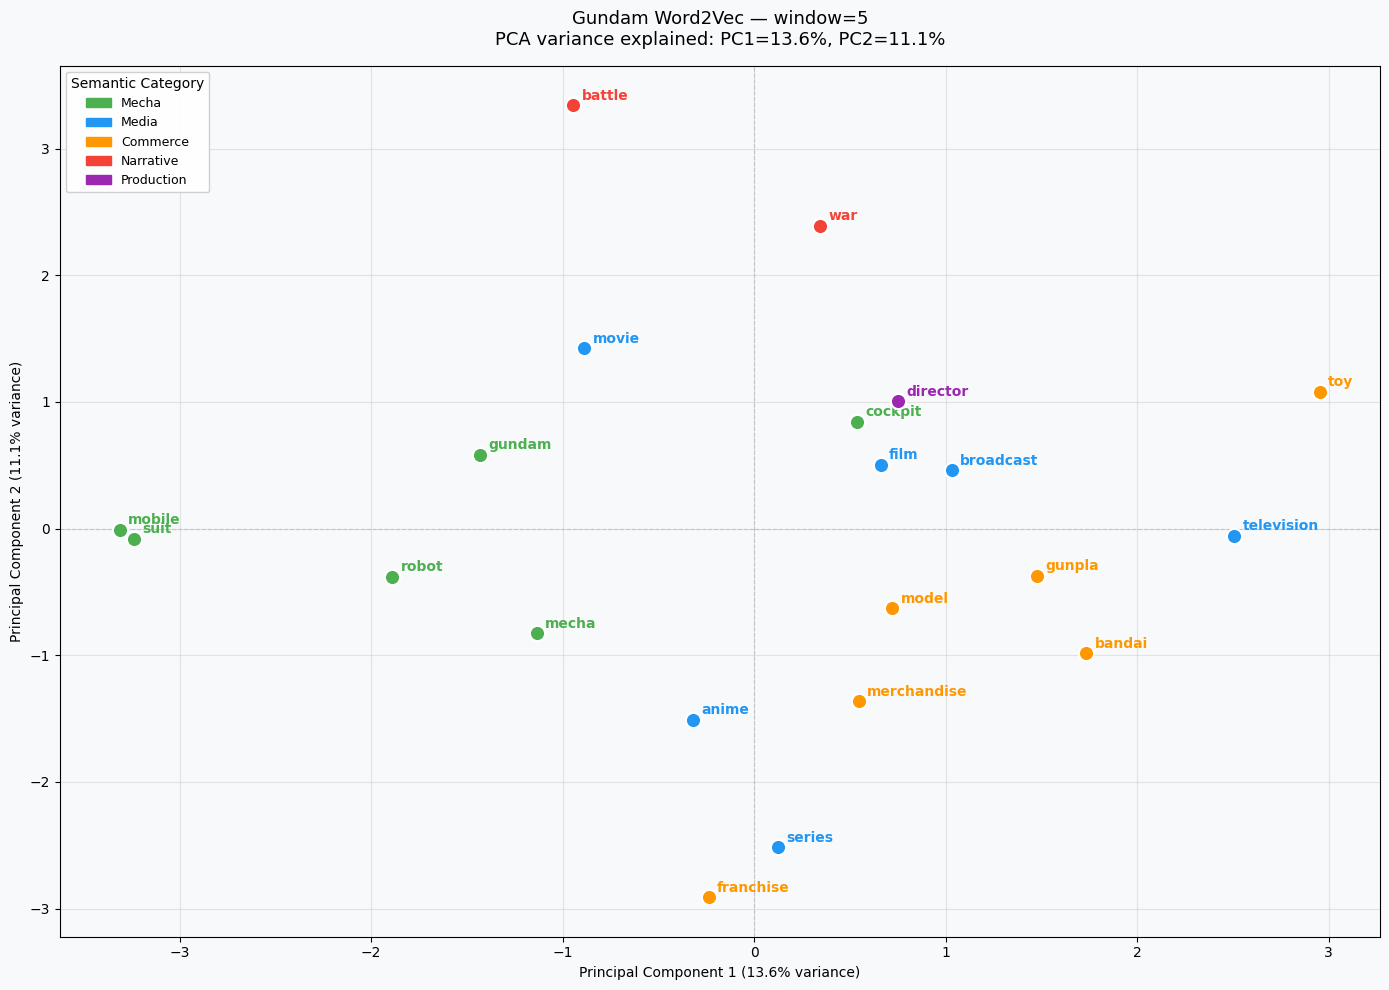

  Saved → pca_gundam_word2vec_—_window=5.png
  Words plotted: 21/25
  OOV (skipped): ['pilot', 'soldier', 'enemy', 'peace']

=== PCA — window=10 model ===


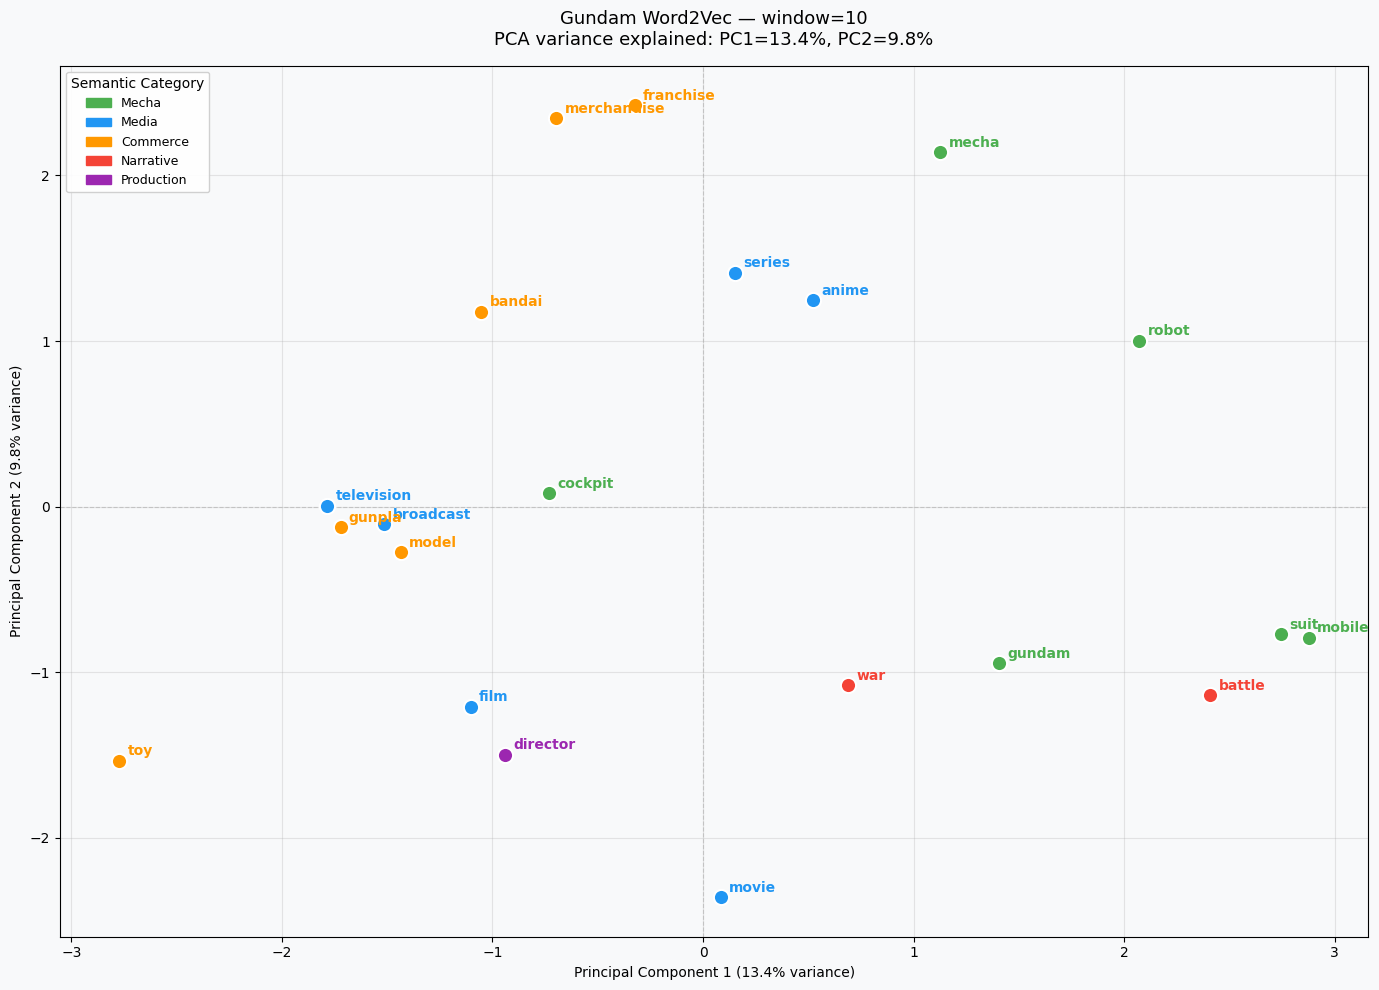

  Saved → pca_gundam_word2vec_—_window=10.png
  Words plotted: 21/25
  OOV (skipped): ['pilot', 'soldier', 'enemy', 'peace']


In [9]:
def plot_pca(model: Word2Vec, words: List[str], title: str = "Word2Vec PCA"):
    valid_words = [w for w in words if has_word(model, w)]
    if len(valid_words) < 2:
        print("Not enough in-vocabulary words for PCA.")
        return

    vectors = np.array([model.wv[w] for w in valid_words])
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(vectors)
    var_explained = pca.explained_variance_ratio_

    category_map = {
        "Mecha":      ["gundam", "robot", "mecha", "suit", "mobile", "cockpit"],
        "Media":      ["anime", "series", "film", "movie", "television", "broadcast"],
        "Commerce":   ["gunpla", "franchise", "merchandise", "toy", "model", "bandai"],
        "Narrative":  ["war", "battle", "pilot", "soldier", "enemy", "peace"],
        "Production": ["director", "producer", "animation", "studio", "creator"],
    }
    category_colors = {
        "Mecha":      "#4CAF50",
        "Media":      "#2196F3",
        "Commerce":   "#FF9800",
        "Narrative":  "#F44336",
        "Production": "#9C27B0",
        "Other":      "#9E9E9E",
    }

    def get_category(word):
        for cat, members in category_map.items():
            if word in members:
                return cat
        return "Other"

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("#F8F9FA")

    for i, word in enumerate(valid_words):
        x, y  = coords[i]
        cat   = get_category(word)
        color = category_colors[cat]
        ax.scatter(x, y, color=color, s=120, zorder=3, edgecolors="white", linewidths=1.5)
        ax.annotate(word, xy=(x, y), xytext=(6, 4),
                    textcoords="offset points", fontsize=10,
                    color=color, fontweight="bold")

    ax.axhline(0, color="#CCCCCC", linewidth=0.8, linestyle="--", zorder=1)
    ax.axvline(0, color="#CCCCCC", linewidth=0.8, linestyle="--", zorder=1)

    legend_handles = [
        mpatches.Patch(color=color, label=cat)
        for cat, color in category_colors.items()
        if any(get_category(w) == cat for w in valid_words)
    ]
    ax.legend(handles=legend_handles, loc="upper left",
              framealpha=0.9, fontsize=9, title="Semantic Category")

    ax.set_title(
        f"{title}\nPCA variance explained: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}",
        fontsize=13, pad=15
    )
    ax.set_xlabel(f"Principal Component 1 ({var_explained[0]:.1%} variance)", fontsize=10)
    ax.set_ylabel(f"Principal Component 2 ({var_explained[1]:.1%} variance)", fontsize=10)
    ax.grid(True, alpha=0.3, zorder=0)

    plt.tight_layout()
    filename = f"pca_{title.replace(' ', '_').lower()}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {filename}")
    print(f"  Words plotted: {len(valid_words)}/{len(words)}")
    oov = [w for w in words if not has_word(model, w)]
    if oov:
        print(f"  OOV (skipped): {oov}")

# ── 25 target words ───────────────────────────────────────────
pca_words = [
    "gundam",  "robot",        "mecha",       "suit",     "mobile",    "cockpit",
    "anime",   "series",       "film",        "movie",    "television","broadcast",
    "gunpla",  "franchise",    "merchandise", "toy",      "model",     "bandai",
    "war",     "battle",       "pilot",       "soldier",  "enemy",     "peace",
    "director"
]

print("=== PCA — window=5 model ===")
plot_pca(model_w5,  pca_words, title="Gundam Word2Vec — window=5")

print("\n=== PCA — window=10 model ===")
plot_pca(model_w10, pca_words, title="Gundam Word2Vec — window=10")

`Save Models`

In [10]:
model_w5.save("sgns_window5.model")
model_w10.save("sgns_window10.model")
print("Saved: sgns_window5.model")
print("Saved: sgns_window10.model")
print("\nAll done!")

Saved: sgns_window5.model
Saved: sgns_window10.model

All done!
